# Deep Q-Learning (DQN) from scratch — CartPole

**Goal:** learn the core ideas of *value-based* reinforcement learning and Deep Q-Networks (DQN) on a task simple enough to watch the agent improve in a couple of minutes.

## Value-based vs. policy-based

There are two big families of deep RL methods, and it is easy to confuse them:

| | **Value-based** (this notebook) | **Policy-based** |
|---|---|---|
| Network outputs | one **Q-value per action**, $Q(s,a)$ | a **probability** over actions, $\pi(a\mid s)$ |
| How we act | pick $\arg\max_a Q(s,a)$ (+ ε-greedy) | **sample** from $\pi(a\mid s)$ |
| What we train on | **TD / Bellman target** $r+\gamma\max_{a'}Q(s',a')$ | **policy gradient** $\nabla \log\pi(a\mid s)\cdot\text{return}$ |
| Examples | Q-learning, **DQN** | REINFORCE, A2C, PPO |

DQN is **value-based**. One naming point to keep in mind: DQN uses two copies of the Q-network, and the online one is conventionally called `policy_net`. That name does **not** make it a policy-gradient method — it just means the (greedy) policy is *read off* from that network. There is no probability distribution over actions and no policy gradient anywhere in DQN.

## The DQN recipe

1. A neural net $Q_\theta(s,\cdot)$ estimates the value of each action in state $s$.
2. **Replay memory:** store transitions $(s,a,r,s')$ and train on random minibatches, which breaks the correlation between consecutive steps.
3. **Target network** $Q_{\theta^-}$: a slowly-updated copy used to compute the learning target, for stability.
4. **ε-greedy** exploration: act randomly with probability ε (decaying over time), greedily otherwise.
5. Minimise the **temporal-difference error** between $Q_\theta(s,a)$ and $r+\gamma\max_{a'}Q_{\theta^-}(s',a')$.


In [1]:
!pip install "gymnasium[classic-control]" imageio --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 112.4 MB/s eta 0:00:00


In [2]:
import math, random
from collections import namedtuple, deque
from itertools import count

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import imageio
from IPython.display import clear_output, Image as IPImage, display

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Reproducibility (optional, nice for a classroom demo)
SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

Using device: cuda


## 1. The environment: CartPole

The agent pushes a cart left/right to keep a pole balanced. The **state** is a 4-D vector (cart position, cart velocity, pole angle, pole angular velocity). You get **+1 reward per timestep** the pole stays up; an episode ends when it falls or after 500 steps. So *episode length = return*, and a perfect agent reaches 500.

Because the state is only 4 numbers, the network is tiny and training is fast. The appendix at the end covers what changes for pixel-based Atari.

In [3]:
env = gym.make("CartPole-v1")                        # fast, no rendering, used for training
render_env = gym.make("CartPole-v1", render_mode="rgb_array")  # used only to record gameplay GIFs

n_observations = env.observation_space.shape[0]   # 4
n_actions = env.action_space.n                     # 2 (left, right)
print("state dim:", n_observations, "| n_actions:", n_actions)

state dim: 4 | n_actions: 2


## 2. Replay memory

Consecutive transitions are highly correlated, which destabilises training. We store transitions in a ring buffer and sample **random minibatches** from it.

In [4]:
# A single transition = one step of experience: the state we were in, the action we took,
# the state we landed in (next_state), and the reward we got. namedtuple lets us access
# fields by name (t.state, t.reward) instead of by index, which keeps the batching code readable.
Transition = namedtuple("Transition", ("state", "action", "next_state", "reward"))

class ReplayMemory:
    def __init__(self, capacity):
        # Create a fixed-size buffer. deque(maxlen=capacity) automatically discards the
        # oldest transition once it's full, so memory holds only the most recent `capacity` steps.
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        # Store one transition. Called as push(state, action, next_state, reward); the *args
        # are packed into a Transition namedtuple and appended to the buffer.
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        # Draw a random minibatch of transitions for training. Sampling *randomly* breaks the
        # strong correlation between consecutive steps, which is what makes the gradient updates stable.
        return random.sample(self.memory, batch_size)

    def __len__(self):
        # How many transitions are currently stored. Lets us call len(memory) and, in the training
        # loop, wait until we have at least BATCH_SIZE transitions before optimising.
        return len(self.memory)

## 3. The Q-network

A small ReLU MLP: input = state (4 numbers), output = one Q-value per action (2 numbers).

In [5]:
class DQN(nn.Module):
    def __init__(self, n_obs, n_act):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_obs, 128), nn.ReLU(),
            nn.Linear(128, 128),   nn.ReLU(),
            nn.Linear(128, n_act),          # one Q-value per action
        )
    def forward(self, x):
        return self.net(x)

## 4. Hyperparameters, networks, ε-greedy action selection

- `GAMMA`: discount factor.
- `EPS_*`: control exploration. ε starts high (explore) and decays toward a small floor (exploit).
- Optimiser: **AdamW** at a modest learning rate.
- **Soft target update** (`TAU`): every step we nudge the target a tiny fraction toward the online net, $\theta^- \leftarrow \tau\theta + (1-\tau)\theta^-$.

In [6]:
BATCH_SIZE = 128
GAMMA      = 0.99
EPS_START  = 0.9
EPS_END    = 0.05
EPS_DECAY  = 1000     # in steps; larger = slower decay = more exploration
TAU        = 0.005    # soft target-update rate
LR         = 1e-4

policy_net = DQN(n_observations, n_actions).to(device)   # online network: acts and is trained
target_net = DQN(n_observations, n_actions).to(device)   # slow copy used for the TD target
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = ReplayMemory(10000)
steps_done = 0

def select_action(state):
    # epsilon-greedy: with prob. eps act randomly, else take argmax Q (value-based control)
    global steps_done
    eps = EPS_END + (EPS_START - EPS_END) * math.exp(-steps_done / EPS_DECAY)
    steps_done += 1
    if random.random() > eps:
        with torch.no_grad():
            return policy_net(state).max(1).indices.view(1, 1)
    else:
        return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)

## 5. One optimisation step (the heart of DQN)

For a minibatch of transitions $(s,a,r,s')$ we:

1. Compute the **predicted** value of the action taken: $Q_\theta(s,a)$.
2. Compute the **target** with the *target* network and the Bellman equation:
$$y = r + \gamma \max_{a'} Q_{\theta^-}(s',a')$$
For terminal states there is no next state, so $y=r$.
3. Minimise the **Huber (smooth-L1)** loss between prediction and target.

Gradients must **not** flow through the target (`torch.no_grad()`), otherwise the objective becomes a moving target and training diverges.

In [7]:
def optimize_model():
    if len(memory) < BATCH_SIZE:
        return
    transitions = memory.sample(BATCH_SIZE)

    # Regroup the list of transitions into per-field lists (same result, more explicit)
    state_batch  = torch.cat([t.state  for t in transitions])
    action_batch = torch.cat([t.action for t in transitions])
    reward_batch = torch.cat([t.reward for t in transitions])

    # next_state needs care because terminal steps stored None
    non_final_mask = torch.tensor([t.next_state is not None for t in transitions],
                                  device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([t.next_state for t in transitions
                                      if t.next_state is not None])

    # ---- PREDICTION: comes from policy_net (the network we are training) ----
    # policy_net(state_batch) gives Q-values for every action; .gather(1, action_batch)
    # picks out Q(s, a) for the action we actually took. These values ARE part of the
    # computation graph, so gradients will flow back into policy_net's weights.
    state_action_values = policy_net(state_batch).gather(1, action_batch)

    # ---- TARGET: comes from target_net (the frozen reference network) ----
    # We estimate the best achievable value of the next state, max_a' Q(s', a'), using
    # target_net — NOT policy_net. It is wrapped in torch.no_grad() so no gradients ever
    # flow into target_net: it is treated as a fixed lookup table for this update.
    # Terminal states keep value 0 (there is no future beyond them).
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1).values

    # Bellman target: immediate reward + discounted value of where we ended up.
    # This is what we want policy_net's prediction to move toward.
    expected_state_action_values = reward_batch + GAMMA * next_state_values

    # Loss = distance between policy_net's prediction and the target_net-based target.
    loss = nn.functional.smooth_l1_loss(
        state_action_values, expected_state_action_values.unsqueeze(1))

    # ---- THE ACTUAL WEIGHT UPDATE: only policy_net changes here ----
    optimizer.zero_grad()          # clear old gradients
    loss.backward()                # backprop: gradients land only on policy_net (target_net is detached)
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)  # guard against exploding grads
    optimizer.step()               # update policy_net's weights; target_net is untouched
    return loss.item()



## 6. Training

Per step we pick an action, step the environment, store the transition, optimise, and soft-update the target.

We keep a **live view** with two things:
- the learning curve (episode return vs. episode), and
- a **gameplay GIF recorded every 50 episodes** by playing one greedy episode with the current network, so you can watch the policy get better while training runs.

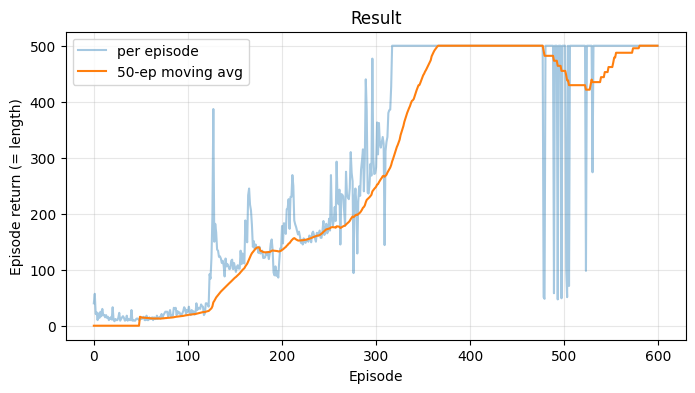

Greedy gameplay at episode 550: survived 500 steps


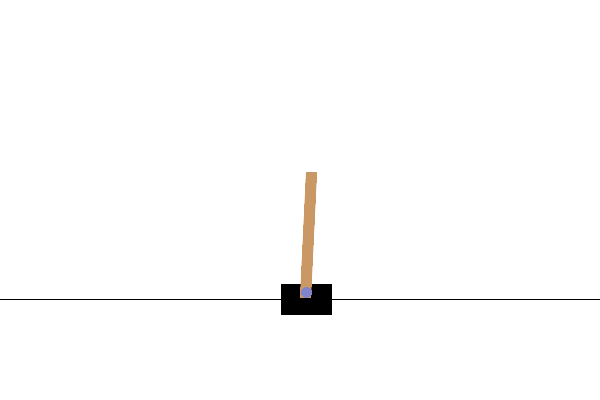

Done. Mean return over last 50 episodes: 500.0


In [8]:
def to_state(obs):
    return torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)

@torch.no_grad()
def record_gameplay(path="progress.gif"):
    # Play one greedy episode (eps = 0) in the render env and save it as a GIF.
    obs, _ = render_env.reset()
    state = to_state(obs)
    frames = []
    for _ in range(500):
        frames.append(render_env.render())
        action = policy_net(state).max(1).indices.view(1, 1)
        obs, _, terminated, truncated, _ = render_env.step(action.item())
        if terminated or truncated:
            break
        state = to_state(obs)
    imageio.mimsave(path, frames, fps=30)
    return path, len(frames)

def live_view(durations, gif_path=None, gif_len=None, gif_episode=None, final=False):
    clear_output(wait=True)
    plt.figure(figsize=(8, 4))
    d = torch.tensor(durations, dtype=torch.float)
    plt.title("Result" if final else "Training…")
    plt.xlabel("Episode"); plt.ylabel("Episode return (= length)")
    plt.plot(d.numpy(), alpha=0.4, label="per episode")
    if len(d) >= 50:
        means = d.unfold(0, 50, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(49), means))
        plt.plot(means.numpy(), label="50-ep moving avg")
    plt.legend(); plt.grid(alpha=0.3); plt.show()
    # Re-display the most recent gameplay GIF so it persists across curve refreshes
    if gif_path is not None:
        print(f"Greedy gameplay at episode {gif_episode}: survived {gif_len} steps")
        display(IPImage(filename=gif_path))

num_episodes = 600           # how many full games to play; each game trains the network many times
episode_durations = []       # length (= return) of each episode, for the learning curve
latest_gif = latest_len = latest_ep = None   # bookkeeping for the most recent gameplay GIF

# ---- OUTER LOOP: one iteration = one full episode (one game) ----
for i_episode in range(num_episodes):
    obs, _ = env.reset()          # start a fresh game; obs is the initial 4-D state
    state = to_state(obs)         # wrap it as a [1, 4] float tensor on the right device

    # ---- INNER LOOP: one iteration = one timestep. count() = 0,1,2,... with no fixed end,
    #      so the episode runs until the game ends (we break out below).
    for t in count():
        action = select_action(state)          # epsilon-greedy: explore or take argmax Q
        obs, reward, terminated, truncated, _ = env.step(action.item())
        reward = torch.tensor([reward], device=device)   # +1 per surviving step, as a tensor

        # Two ways an episode ends:
        #   terminated = failure — either the pole tipped past +/-12 degrees OR the cart ran
        #                off the track (position past +/-2.4). No meaningful future -> next_state = None.
        #   truncated  = hit the 500-step time limit (the agent was still fine, we just stop).
        done = terminated or truncated

        # Only a genuine failure has "no future". On truncation the state was actually fine,
        # but we still stop the loop. Storing None lets optimize_model() zero out the future
        # value for terminal steps.
        next_state = None if terminated else to_state(obs)

        # Save this step of experience into the replay buffer for later sampling.
        memory.push(state, action, next_state, reward)
        state = next_state          # advance: the new state becomes the current one

        optimize_model()            # ONE gradient step on policy_net using a random minibatch.
                                    # Note this runs EVERY timestep, so 600 episodes = many thousands of updates.

        # ---- Soft update of target_net, every step ----
        # Nudge target_net a tiny fraction (TAU = 0.005) toward policy_net, weight by weight.
        # This is the "slow-moving reference" update: target_net trails policy_net so the
        # Bellman target stays stable instead of chasing itself.
        target_sd = target_net.state_dict()
        policy_sd = policy_net.state_dict()
        for key in policy_sd:
            target_sd[key] = policy_sd[key] * TAU + target_sd[key] * (1 - TAU)
        target_net.load_state_dict(target_sd)

        if done:                              # pole fell, cart left the track, or time limit reached
            episode_durations.append(t + 1)  # t starts at 0, so length = t + 1
            break                             # end this episode, go to the next game

    # ---- Everything below runs once per episode, not per step ----

    # Every 50 episodes, play one greedy game and save it as a GIF, so we can watch the
    # policy visibly improve over the course of training.
    if i_episode % 50 == 0:
        latest_gif, latest_len = record_gameplay()
        latest_ep = i_episode

    # Every 10 episodes, redraw the live dashboard (learning curve + most recent GIF).
    # We pass the latest GIF each time so it stays on screen between the 50-episode refreshes.
    if i_episode % 10 == 0:
        live_view(episode_durations, latest_gif, latest_len, latest_ep)

# After training: draw the final curve and report how well the agent did recently.
live_view(episode_durations, latest_gif, latest_len, latest_ep, final=True)
print("Done. Mean return over last 50 episodes:", np.mean(episode_durations[-50:]))

## 7. Final trained agent

One more greedy episode, recorded at full length.

Survived 500 steps


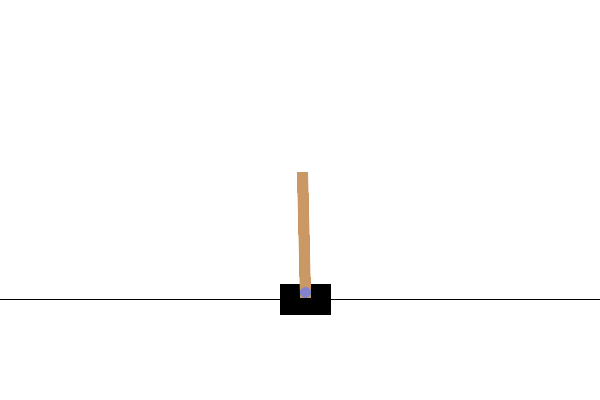

In [9]:
gif_path, length = record_gameplay("cartpole_final.gif")
print(f"Survived {length} steps")
display(IPImage(filename=gif_path))
env.close(); render_env.close()

## Exercises

1. **Break it on purpose.** Set `EPS_DECAY = 50` so ε collapses almost immediately. What happens to the learning curve, and why? (Exploration vs. exploitation.)
2. **Target network ablation.** Use `policy_net` in place of `target_net` inside `optimize_model`. Training often becomes unstable — explain why in terms of a moving target.
3. **Replay ablation.** Set `BATCH_SIZE = 1` and train only on the most recent transition. What role was the replay buffer playing?
5. **γ sweep.** Try `GAMMA` ∈ {0.90, 0.99, 1.0}. What does a short vs. long horizon do here?
